# **Step 1: Import and Load Data**

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# for reproducibility
np.random.seed(42)

# load dataset
df = pd.read_csv("/content/car_insurance_premium_dataset.csv")

# clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("/", "_", regex=False)
)

print(df.shape)
df.head()

(1000, 7)


,driver_age,driver_experience,previous_accidents,annual_mileage_x1000_km,car_manufacturing_year,car_age,insurance_premium_
0,56,32,4,17,2002,23,488.35
1,46,19,0,21,2025,0,486.15
2,32,11,4,15,2020,5,497.55
3,60,0,4,19,1991,34,498.35
4,25,7,0,13,2005,20,495.55


# **Step 2: Renaming Columns**



In [119]:
print(df.columns.tolist())
print(df.isnull().sum())

df = df.rename(columns={
    "driver_age": "driver_age",
    "driver_experience": "driver_experience",
    "previous_accidents": "previous_accidents",
    "annual_mileage_x1000_km": "annual_mileage",
    "car_manufacturing_year": "car_year",
    "car_age": "car_age",
    "insurance_premium_": "premium"
})

df.head()

['driver_age', 'driver_experience', 'previous_accidents', 'annual_mileage_x1000_km', 'car_manufacturing_year', 'car_age', 'insurance_premium_']
driver_age                 0
driver_experience          0
previous_accidents         0
annual_mileage_x1000_km    0
car_manufacturing_year     0
car_age                    0
insurance_premium_         0
dtype: int64


,driver_age,driver_experience,previous_accidents,annual_mileage,car_year,car_age,premium
0,56,32,4,17,2002,23,488.35
1,46,19,0,21,2025,0,486.15
2,32,11,4,15,2020,5,497.55
3,60,0,4,19,1991,34,498.35
4,25,7,0,13,2005,20,495.55


        driver_age  driver_experience  previous_accidents  annual_mileage  \
count  1000.000000        1000.000000           1000.0000     1000.000000   
mean     41.575000          14.759000              2.5680       17.933000   
std      13.765677          10.544292              1.6989        4.410665   
min      18.000000           0.000000              0.0000       11.000000   
25%      30.000000           6.000000              1.0000       14.000000   
50%      42.000000          13.000000              3.0000       18.000000   
75%      53.000000          23.000000              4.0000       22.000000   
max      65.000000          40.000000              5.0000       25.000000   

          car_year      car_age      premium  
count  1000.000000  1000.000000  1000.000000  
mean   2007.637000    17.363000   493.742250  
std      10.363331    10.363331     5.909689  
min    1990.000000     0.000000   477.050000  
25%    1999.000000     8.000000   489.487500  
50%    2008.000000    17

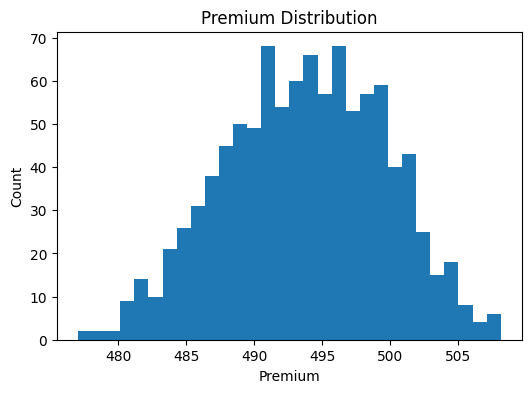

In [120]:
print(df.describe())

plt.figure(figsize=(6,4))
plt.hist(df["premium"], bins=30)
plt.title("Premium Distribution")
plt.xlabel("Premium")
plt.ylabel("Count")
plt.show()

# **Step 3: Simulating multiple quote attempts for each customer. Some customers behave normally while some customers strategically lower inputs to reduce premium**

In [121]:
df = df.copy()
df["customer_id"] = range(1, len(df) + 1)
df.head()

,driver_age,driver_experience,previous_accidents,annual_mileage,car_year,car_age,premium,customer_id
0,56,32,4,17,2002,23,488.35,1
1,46,19,0,21,2025,0,486.15,2
2,32,11,4,15,2020,5,497.55,3
3,60,0,4,19,1991,34,498.35,4
4,25,7,0,13,2005,20,495.55,5


In [122]:
def simulate_quotes_for_customer(row):
    """
    Simulate quote attempts for one customer.
    Manipulative users are only *more likely* to make premium-lowering edits,
    not guaranteed to do so.
    """
    customer_id = int(row["customer_id"])

    # softer class balance
    manipulative = np.random.choice([0, 1], p=[0.7, 0.3])

    # overlapping quote counts
    if manipulative:
        n_quotes = np.random.randint(2, 6)   # 2 to 5
    else:
        n_quotes = np.random.randint(1, 5)   # 1 to 4

    quotes = []

    base_age = row["driver_age"]
    base_experience = row["driver_experience"]
    base_accidents = row["previous_accidents"]
    base_mileage = row["annual_mileage"]
    base_car_age = row["car_age"]

    # start from current values and update cumulatively
    curr_experience = base_experience
    curr_accidents = base_accidents
    curr_mileage = base_mileage
    curr_car_age = base_car_age

    current_time = pd.Timestamp("2026-03-01 09:00:00") + pd.Timedelta(
        minutes=np.random.randint(0, 50000)
    )

    prev_premium = None
    premium_lowering_edits = 0
    total_edits = 0

    for q in range(1, n_quotes + 1):
        if q > 1:
            # overlapping timing distributions
            if manipulative:
                gap = np.random.randint(5, 180)     # 5 min to 3 hrs
            else:
                gap = np.random.randint(10, 400)    # overlaps with manipulative
            current_time += pd.Timedelta(minutes=gap)

            # mileage edit
            if manipulative:
                mileage_change = np.random.choice(
                    [-2.0, -1.5, -1.0, -0.5, 0, 0.5],
                    p=[0.18, 0.2, 0.22, 0.18, 0.15, 0.07]
                )
            else:
                mileage_change = np.random.choice(
                    [-1.0, -0.5, 0, 0.5, 1.0],
                    p=[0.15, 0.2, 0.3, 0.2, 0.15]
                )
            curr_mileage = max(1, curr_mileage + mileage_change)

            # accidents edit: rare, but possible
            if np.random.rand() < (0.18 if manipulative else 0.08):
                accident_change = np.random.choice([-1, 1], p=[0.7, 0.3])
                curr_accidents = max(0, curr_accidents + accident_change)

            # experience edit: small declaration drift
            if np.random.rand() < (0.22 if manipulative else 0.12):
                exp_change = np.random.choice([0, 1], p=[0.4, 0.6]) if manipulative else np.random.choice([-1, 0, 1], p=[0.15, 0.7, 0.15])
                curr_experience = max(0, min(curr_experience + exp_change, base_age - 17))

        # premium formula
        simulated_premium = (
            220
            + 3.2 * curr_mileage
            + 22 * curr_accidents
            - 1.8 * curr_experience
            + 1.4 * curr_car_age
            + np.random.normal(0, 8)
        )
        simulated_premium = max(150, simulated_premium + 250)

        # track whether latest edit lowered premium
        if prev_premium is not None:
            total_edits += 1
            if simulated_premium < prev_premium:
                premium_lowering_edits += 1

        quotes.append({
            "customer_id": customer_id,
            "quote_number": q,
            "quote_time": current_time,
            "driver_age": base_age,
            "driver_experience": curr_experience,
            "previous_accidents": curr_accidents,
            "annual_mileage": curr_mileage,
            "car_age": curr_car_age,
            "premium": simulated_premium,
            "is_manipulative": manipulative
        })

        prev_premium = simulated_premium

    return quotes

In [123]:
all_quotes = []

for _, row in df.iterrows():
    all_quotes.extend(simulate_quotes_for_customer(row))

quotes_df = pd.DataFrame(all_quotes)
quotes_df = quotes_df.sort_values(["customer_id", "quote_number"]).reset_index(drop=True)

print(quotes_df.shape)
quotes_df.head(10)

(2746, 10)


,customer_id,quote_number,quote_time,driver_age,driver_experience,previous_accidents,annual_mileage,car_age,premium,is_manipulative
0,1,1,2026-03-27 20:58:00,56.0,32.0,4.0,17.0,23.0,592.181508,0
1,2,1,2026-03-27 04:54:00,46.0,19.0,0.0,21.0,0.0,515.184239,0
2,2,2,2026-03-27 06:31:00,46.0,19.0,0.0,20.5,0.0,502.038654,0
3,2,3,2026-03-27 11:34:00,46.0,19.0,0.0,19.5,0.0,496.923868,0
4,3,1,2026-03-20 11:00:00,32.0,11.0,4.0,15.0,5.0,599.731561,0
5,4,1,2026-03-03 06:47:00,60.0,0.0,4.0,19.0,34.0,654.208992,0
6,4,2,2026-03-03 11:27:00,60.0,0.0,4.0,19.0,34.0,686.875904,0
7,4,3,2026-03-03 13:47:00,60.0,0.0,4.0,20.0,34.0,672.753864,0
8,4,4,2026-03-03 18:30:00,60.0,0.0,4.0,21.0,34.0,667.994890,0
9,5,1,2026-03-17 16:23:00,25.0,7.0,0.0,13.0,20.0,524.666450,0


In [124]:
quotes_df.groupby("customer_id").size().value_counts().sort_index()

,count
1,171
2,282
3,246
4,232
5,69


In [125]:
sample_ids = quotes_df["customer_id"].drop_duplicates().sample(5, random_state=42).tolist()

for cid in sample_ids:
    print(f"\nCustomer {cid}")
    display(quotes_df[quotes_df["customer_id"] == cid][[
        "quote_number", "quote_time", "annual_mileage",
        "previous_accidents", "driver_experience",
        "premium", "is_manipulative"
    ]])


Customer 522


,quote_number,quote_time,annual_mileage,previous_accidents,driver_experience,premium,is_manipulative
1423,1,2026-03-20 06:48:00,25.0,3.0,9.0,630.920159,0
1424,2,2026-03-20 08:31:00,25.0,3.0,9.0,624.322534,0



Customer 738


,quote_number,quote_time,annual_mileage,previous_accidents,driver_experience,premium,is_manipulative
2011,1,2026-03-14 08:00:00,25.0,5.0,7.0,645.251145,0
2012,2,2026-03-14 08:29:00,24.5,5.0,7.0,646.258761,0
2013,3,2026-03-14 11:51:00,24.0,5.0,7.0,645.720222,0



Customer 741


,quote_number,quote_time,annual_mileage,previous_accidents,driver_experience,premium,is_manipulative
2017,1,2026-04-04 14:34:00,16.0,0.0,16.0,534.724797,0
2018,2,2026-04-04 19:35:00,16.0,0.0,16.0,533.017170,0
2019,3,2026-04-05 02:06:00,17.0,0.0,16.0,529.699394,0



Customer 661


,quote_number,quote_time,annual_mileage,previous_accidents,driver_experience,premium,is_manipulative
1804,1,2026-03-03 09:31:00,23.0,5.0,7.0,665.366974,0
1805,2,2026-03-03 10:49:00,22.0,4.0,7.0,629.050399,0



Customer 412


,quote_number,quote_time,annual_mileage,previous_accidents,driver_experience,premium,is_manipulative
1125,1,2026-04-01 20:37:00,17.0,5.0,17.0,657.671714,0
1126,2,2026-04-01 22:14:00,16.5,6.0,17.0,672.880575,0
1127,3,2026-04-02 03:53:00,17.0,6.0,17.0,663.578117,0


# **Step 4: Feature Engineering (to find behavior features)**

In [126]:
feature_rows = []

for customer_id, grp in quotes_df.groupby("customer_id"):
    grp = grp.sort_values("quote_number").reset_index(drop=True)

    n_quotes = len(grp)
    first_premium = grp.loc[0, "premium"]
    last_premium = grp.loc[n_quotes - 1, "premium"]
    premium_drop_pct = ((first_premium - last_premium) / first_premium) * 100

    mileage_changes = grp["annual_mileage"].diff().fillna(0)
    accident_changes = grp["previous_accidents"].diff().fillna(0)
    exp_changes = grp["driver_experience"].diff().fillna(0)
    premium_changes = grp["premium"].diff().fillna(0)

    mileage_decrease_count = int((mileage_changes < 0).sum())
    accident_decrease_count = int((accident_changes < 0).sum())
    experience_increase_count = int((exp_changes > 0).sum())

    premium_lowering_edit_count = int((premium_changes < 0).sum())
    premium_lowering_edit_ratio = (
        premium_lowering_edit_count / (n_quotes - 1) if n_quotes > 1 else 0
    )

    time_diffs = grp["quote_time"].diff().dropna()
    avg_minutes_between_quotes = (
        time_diffs.dt.total_seconds().mean() / 60 if len(time_diffs) > 0 else np.nan
    )
    min_minutes_between_quotes = (
        time_diffs.dt.total_seconds().min() / 60 if len(time_diffs) > 0 else np.nan
    )

    monotonic_premium_drop = int(n_quotes > 1 and grp["premium"].is_monotonic_decreasing)

    feature_rows.append({
        "customer_id": int(customer_id),
        "n_quotes": n_quotes,
        "premium_drop_pct": premium_drop_pct,
        "mileage_decrease_count": mileage_decrease_count,
        "accident_decrease_count": accident_decrease_count,
        "experience_increase_count": experience_increase_count,
        "premium_lowering_edit_count": premium_lowering_edit_count,
        "premium_lowering_edit_ratio": premium_lowering_edit_ratio,
        "avg_minutes_between_quotes": avg_minutes_between_quotes,
        "min_minutes_between_quotes": min_minutes_between_quotes,
        "monotonic_premium_drop": monotonic_premium_drop,
        "label": int(grp["is_manipulative"].iloc[0])
    })

features_df = pd.DataFrame(feature_rows)

# fill NaNs for customers with only 1 quote
features_df["avg_minutes_between_quotes"] = features_df["avg_minutes_between_quotes"].fillna(999)
features_df["min_minutes_between_quotes"] = features_df["min_minutes_between_quotes"].fillna(999)

features_df.head()

,customer_id,n_quotes,premium_drop_pct,mileage_decrease_count,accident_decrease_count,experience_increase_count,premium_lowering_edit_count,premium_lowering_edit_ratio,avg_minutes_between_quotes,min_minutes_between_quotes,monotonic_premium_drop,label
0,1,1,0.000000,0,0,0,0,0.000000,999.000000,999.0,0,0
1,2,3,3.544435,2,0,0,2,1.000000,200.000000,97.0,1,0
2,3,1,0.000000,0,0,0,0,0.000000,999.000000,999.0,0,0
3,4,4,-2.107262,0,0,0,2,0.666667,234.333333,140.0,0,0
4,5,3,-1.194947,2,0,0,1,0.500000,336.000000,273.0,0,0


In [127]:
features_df["rule_flag"] = (
    (features_df["n_quotes"] >= 3) &
    (features_df["premium_drop_pct"] > 4) &
    (features_df["premium_lowering_edit_ratio"] >= 0.6) &
    (features_df["avg_minutes_between_quotes"] < 180)
).astype(int)

print(classification_report(features_df["label"], features_df["rule_flag"]))
print(confusion_matrix(features_df["label"], features_df["rule_flag"]))

              precision    recall  f1-score   support

           0       0.74      0.99      0.85       710
           1       0.89      0.16      0.27       290

    accuracy                           0.75      1000
   macro avg       0.82      0.58      0.56      1000
weighted avg       0.78      0.75      0.68      1000

[[704   6]
 [243  47]]


# **Step 5: Training a classifier (Random Forest)**

In [128]:
model_features = [
    "n_quotes",
    "premium_drop_pct",
    "mileage_decrease_count",
    "accident_decrease_count",
    "experience_increase_count",
    "premium_lowering_edit_count",
    "premium_lowering_edit_ratio",
    "avg_minutes_between_quotes",
    "min_minutes_between_quotes",
    "monotonic_premium_drop"
]

X = features_df[model_features]
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [129]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# train final model on full dataset
rf = RandomForestClassifier(n_estimators=200, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring="f1")
print("F1 scores for each fold:", scores)
print("Mean F1:", scores.mean())
print("Std:", scores.std())

rf.fit(X, y)


F1 scores for each fold: [0.77876106 0.83185841 0.84482759 0.77586207 0.7804878 ]
Mean F1: 0.8023593858154022
Std: 0.029702171780479028


RandomForestClassifier(n_estimators=200, random_state=42)

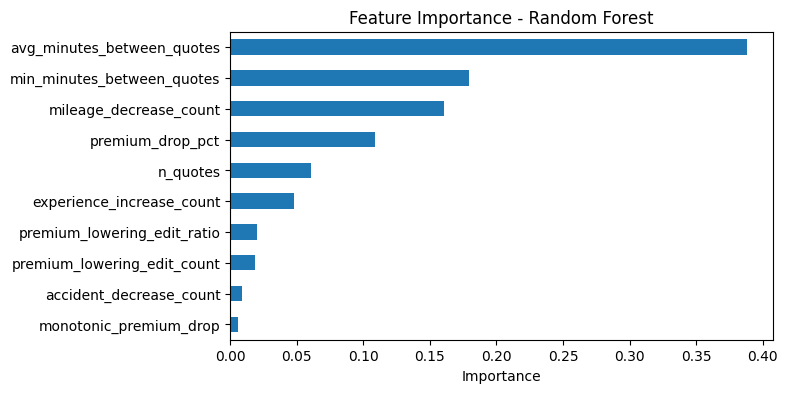

In [130]:
#feature importance
importances = pd.Series(rf.feature_importances_, index=model_features).sort_values()

plt.figure(figsize=(7,4))
importances.plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [131]:
#anomaly detection with isolation forest
iso = IsolationForest(contamination=0.25, random_state=42)
iso.fit(X)

features_df["anomaly_score"] = iso.decision_function(X)
features_df["iso_flag"] = (iso.predict(X) == -1).astype(int)

print(classification_report(features_df["label"], features_df["iso_flag"]))
print(confusion_matrix(features_df["label"], features_df["iso_flag"]))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       710
           1       0.59      0.51      0.54       290

    accuracy                           0.75      1000
   macro avg       0.70      0.68      0.69      1000
weighted avg       0.75      0.75      0.75      1000

[[607 103]
 [143 147]]


# **Step 6: Visualising suspicious patterns**

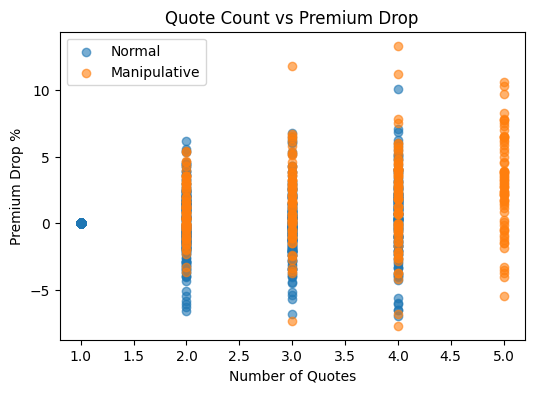

In [132]:
plt.figure(figsize=(6,4))
for label, name in [(0, "Normal"), (1, "Manipulative")]:
    subset = features_df[features_df["label"] == label]
    plt.scatter(
        subset["n_quotes"],
        subset["premium_drop_pct"],
        alpha=0.6,
        label=name
    )

plt.xlabel("Number of Quotes")
plt.ylabel("Premium Drop %")
plt.title("Quote Count vs Premium Drop")
plt.legend()
plt.show()

In [133]:
from sklearn.model_selection import cross_val_predict

rf_for_scores = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# generate out-of-fold probabilities
oof_probs = cross_val_predict(
    rf_for_scores,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

features_df["rf_prob_oof"] = oof_probs

# find most suspicious customers based on out-of-fold risk scores
top_cases = features_df.sort_values("rf_prob_oof", ascending=False).head(10)

top_cases

,customer_id,n_quotes,premium_drop_pct,mileage_decrease_count,accident_decrease_count,experience_increase_count,premium_lowering_edit_count,premium_lowering_edit_ratio,avg_minutes_between_quotes,min_minutes_between_quotes,monotonic_premium_drop,label,rule_flag,anomaly_score,iso_flag,rf_prob_oof
934,935,5,3.450740,4,0,1,4,1.00,63.50,29.0,1,1,0,-0.145741,1,1.0
402,403,5,7.788715,4,1,1,4,1.00,65.75,14.0,1,1,1,-0.166357,1,1.0
67,68,5,6.144019,3,1,1,2,0.50,91.50,19.0,0,1,0,-0.061586,1,1.0
940,941,5,6.458056,4,1,2,3,0.75,81.75,24.0,0,1,1,-0.151053,1,1.0
391,392,5,3.583010,3,0,1,3,0.75,92.50,66.0,0,1,0,-0.059415,1,1.0
102,103,5,2.747106,4,0,1,3,0.75,86.75,21.0,0,1,0,-0.075495,1,1.0
889,890,5,6.511359,3,1,1,4,1.00,106.00,51.0,1,1,1,-0.144319,1,1.0
387,388,5,3.896110,2,1,1,3,0.75,66.50,20.0,0,1,0,-0.081311,1,1.0
118,119,5,6.564154,4,1,0,3,0.75,51.25,16.0,0,1,1,-0.094939,1,1.0
128,129,5,2.350207,4,0,1,3,0.75,75.00,29.0,0,1,0,-0.073903,1,1.0


In [134]:
top_customer = int(top_cases.iloc[0]["customer_id"])
quotes_df[quotes_df["customer_id"] == top_customer][[
    "quote_number", "quote_time", "annual_mileage",
    "previous_accidents", "driver_experience", "premium", "is_manipulative"
]]

,quote_number,quote_time,annual_mileage,previous_accidents,driver_experience,premium,is_manipulative
2558,1,2026-03-15 13:49:00,14.0,1.0,1.0,547.588979,1
2559,2,2026-03-15 15:14:00,13.0,1.0,2.0,539.943955,1
2560,3,2026-03-15 16:53:00,12.0,1.0,2.0,539.435613,1
2561,4,2026-03-15 17:22:00,10.0,1.0,2.0,538.144275,1
2562,5,2026-03-15 18:03:00,9.0,1.0,2.0,528.693105,1


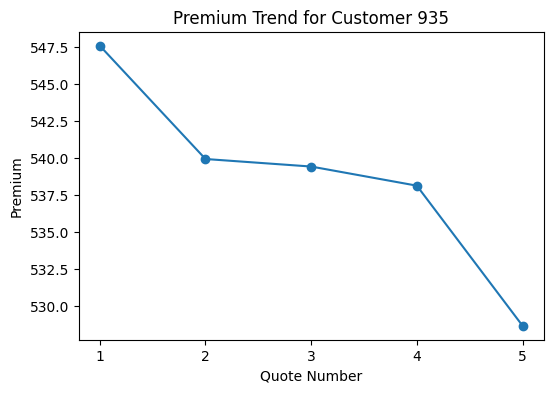

In [135]:
#premium trend for 1 suspicious customer
customer_view = quotes_df[quotes_df["customer_id"] == top_customer].sort_values("quote_number")

plt.figure(figsize=(6,4))
plt.plot(customer_view["quote_number"], customer_view["premium"], marker="o")
plt.title(f"Premium Trend for Customer {top_customer}")
plt.xlabel("Quote Number")
plt.ylabel("Premium")
plt.xticks(customer_view["quote_number"])
plt.show()

# **Step 7: Finding candidate factor summary**

In [136]:
candidate_factors = [
    "n_quotes",
    "premium_drop_pct",
    "mileage_decrease_count",
    "accident_decrease_count",
    "experience_increase_count",
    "premium_lowering_edit_count",
    "premium_lowering_edit_ratio",
    "avg_minutes_between_quotes",
    "min_minutes_between_quotes",
    "monotonic_premium_drop"
]

factor_summary = features_df.groupby("label")[candidate_factors].mean().T
factor_summary.columns = ["Normal_Users", "Manipulative_Users"]
factor_summary["Difference"] = factor_summary["Manipulative_Users"] - factor_summary["Normal_Users"]

factor_summary.sort_values("Difference", ascending=False)

,Normal_Users,Manipulative_Users,Difference
premium_drop_pct,0.132839,1.786598,1.653758
mileage_decrease_count,0.500000,1.882759,1.382759
n_quotes,2.447887,3.475862,1.027975
premium_lowering_edit_count,0.718310,1.510345,0.792035
experience_increase_count,0.026761,0.341379,0.314619
premium_lowering_edit_ratio,0.372535,0.610345,0.237810
accident_decrease_count,0.077465,0.241379,0.163915
monotonic_premium_drop,0.197183,0.306897,0.109713
min_minutes_between_quotes,363.023944,60.986207,-302.037737
avg_minutes_between_quotes,400.967371,92.852586,-308.114785


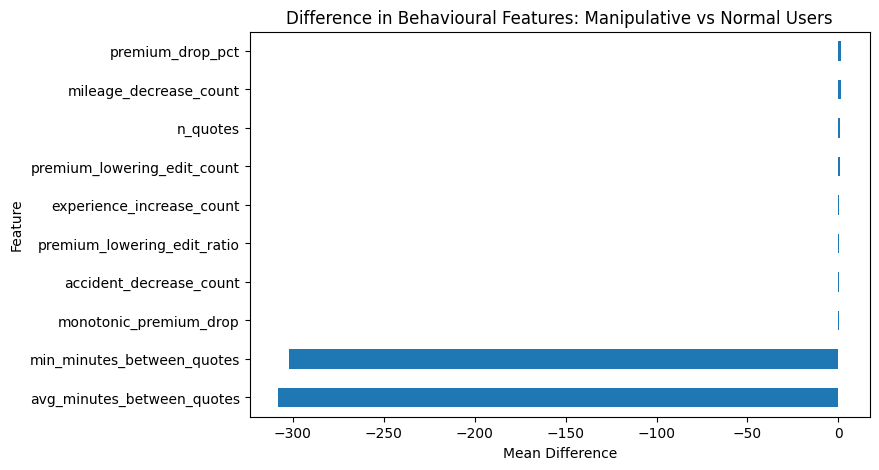

In [137]:
top_diff = factor_summary["Difference"].sort_values()

plt.figure(figsize=(8,5))
top_diff.plot(kind="barh")
plt.title("Difference in Behavioural Features: Manipulative vs Normal Users")
plt.xlabel("Mean Difference")
plt.ylabel("Feature")
plt.show()

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X, y)

lr_model = lr_pipeline.named_steps["lr"]
lr_coefs = pd.Series(lr_model.coef_[0], index=model_features).sort_values()

lr_coefs

,0
avg_minutes_between_quotes,-5.618127
premium_lowering_edit_count,-0.503218
n_quotes,-0.060927
accident_decrease_count,0.045701
premium_lowering_edit_ratio,0.047913
min_minutes_between_quotes,0.116961
premium_drop_pct,0.197695
monotonic_premium_drop,0.314828
experience_increase_count,0.541538
mileage_decrease_count,1.555161


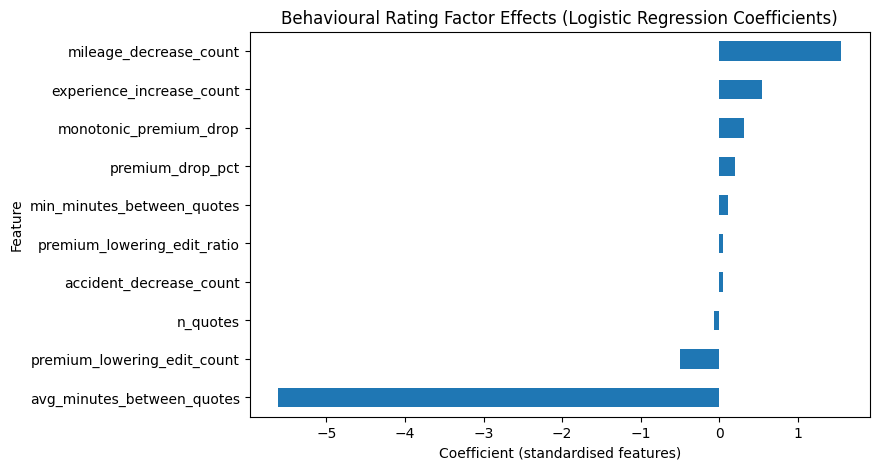

In [139]:
plt.figure(figsize=(8,5))
lr_coefs.plot(kind="barh")
plt.title("Behavioural Rating Factor Effects (Logistic Regression Coefficients)")
plt.xlabel("Coefficient (standardised features)")
plt.ylabel("Feature")
plt.show()

In [140]:
rf_importance = pd.Series(rf.feature_importances_, index=model_features)
lr_abs_coef = lr_coefs.abs()

rating_factor_table = pd.DataFrame({
    "rf_importance": rf_importance,
    "lr_coefficient": lr_coefs,
    "abs_lr_coefficient": lr_abs_coef,
    "normal_mean": features_df[features_df["label"] == 0][model_features].mean(),
    "manipulative_mean": features_df[features_df["label"] == 1][model_features].mean()
})

rating_factor_table["mean_difference"] = (
    rating_factor_table["manipulative_mean"] - rating_factor_table["normal_mean"]
)

rating_factor_table = rating_factor_table.sort_values(
    ["rf_importance", "abs_lr_coefficient"],
    ascending=False
)

rating_factor_table

,rf_importance,lr_coefficient,abs_lr_coefficient,normal_mean,manipulative_mean,mean_difference
avg_minutes_between_quotes,0.387999,-5.618127,5.618127,400.967371,92.852586,-308.114785
min_minutes_between_quotes,0.179549,0.116961,0.116961,363.023944,60.986207,-302.037737
mileage_decrease_count,0.160499,1.555161,1.555161,0.500000,1.882759,1.382759
premium_drop_pct,0.108735,0.197695,0.197695,0.132839,1.786598,1.653758
n_quotes,0.060738,-0.060927,0.060927,2.447887,3.475862,1.027975
experience_increase_count,0.048247,0.541538,0.541538,0.026761,0.341379,0.314619
premium_lowering_edit_ratio,0.020352,0.047913,0.047913,0.372535,0.610345,0.237810
premium_lowering_edit_count,0.018991,-0.503218,0.503218,0.718310,1.510345,0.792035
accident_decrease_count,0.008711,0.045701,0.045701,0.077465,0.241379,0.163915
monotonic_premium_drop,0.006179,0.314828,0.314828,0.197183,0.306897,0.109713


In [141]:
top_rating_factors = rating_factor_table.head(5)
top_rating_factors

,rf_importance,lr_coefficient,abs_lr_coefficient,normal_mean,manipulative_mean,mean_difference
avg_minutes_between_quotes,0.387999,-5.618127,5.618127,400.967371,92.852586,-308.114785
min_minutes_between_quotes,0.179549,0.116961,0.116961,363.023944,60.986207,-302.037737
mileage_decrease_count,0.160499,1.555161,1.555161,0.500000,1.882759,1.382759
premium_drop_pct,0.108735,0.197695,0.197695,0.132839,1.786598,1.653758
n_quotes,0.060738,-0.060927,0.060927,2.447887,3.475862,1.027975


# **Checking Interpretation**

In [142]:
for feature in top_rating_factors.index:
    diff = rating_factor_table.loc[feature, "mean_difference"]
    coef = rating_factor_table.loc[feature, "lr_coefficient"]
    imp = rating_factor_table.loc[feature, "rf_importance"]

    direction = "increases" if coef > 0 else "decreases"

    print(f"{feature}:")
    print(f"  Mean difference (manipulative - normal): {diff:.3f}")
    print(f"  Logistic direction: {direction} manipulation likelihood")
    print(f"  Random Forest importance: {imp:.3f}")
    print()

avg_minutes_between_quotes:
  Mean difference (manipulative - normal): -308.115
  Logistic direction: decreases manipulation likelihood
  Random Forest importance: 0.388

min_minutes_between_quotes:
  Mean difference (manipulative - normal): -302.038
  Logistic direction: increases manipulation likelihood
  Random Forest importance: 0.180

mileage_decrease_count:
  Mean difference (manipulative - normal): 1.383
  Logistic direction: increases manipulation likelihood
  Random Forest importance: 0.160

premium_drop_pct:
  Mean difference (manipulative - normal): 1.654
  Logistic direction: increases manipulation likelihood
  Random Forest importance: 0.109

n_quotes:
  Mean difference (manipulative - normal): 1.028
  Logistic direction: decreases manipulation likelihood
  Random Forest importance: 0.061



# **Step 8: Monitoring under Behavior shift**

In [143]:
def simulate_quotes_for_customer_shifted(row):
    """
    Simulate quote attempts in a shifted environment:
    - more customers quote repeatedly
    - shorter time between quotes overall
    - manipulation still exists, but is harder to separate
    """
    customer_id = int(row["customer_id"])
    manipulative = np.random.choice([0, 1], p=[0.72, 0.28])

    if manipulative:
        n_quotes = np.random.randint(2, 6)
    else:
        n_quotes = np.random.randint(2, 5)   # normal users also quote more now

    quotes = []

    base_age = row["driver_age"]
    base_experience = row["driver_experience"]
    base_accidents = row["previous_accidents"]
    base_mileage = row["annual_mileage"]
    base_car_age = row["car_age"]

    curr_experience = base_experience
    curr_accidents = base_accidents
    curr_mileage = base_mileage
    curr_car_age = base_car_age

    current_time = pd.Timestamp("2026-04-01 09:00:00") + pd.Timedelta(
        minutes=np.random.randint(0, 50000)
    )

    prev_premium = None

    for q in range(1, n_quotes + 1):
        if q > 1:
            # environment shift: everyone quotes faster
            if manipulative:
                gap = np.random.randint(3, 120)
            else:
                gap = np.random.randint(5, 180)
            current_time += pd.Timedelta(minutes=gap)

            # behaviour overlap increases
            if manipulative:
                mileage_change = np.random.choice(
                    [-1.5, -1.0, -0.5, 0, 0.5],
                    p=[0.22, 0.25, 0.22, 0.2, 0.11]
                )
            else:
                mileage_change = np.random.choice(
                    [-1.0, -0.5, 0, 0.5, 1.0],
                    p=[0.18, 0.22, 0.24, 0.2, 0.16]
                )
            curr_mileage = max(1, curr_mileage + mileage_change)

            if np.random.rand() < (0.15 if manipulative else 0.10):
                accident_change = np.random.choice([-1, 1], p=[0.65, 0.35])
                curr_accidents = max(0, curr_accidents + accident_change)

            if np.random.rand() < (0.18 if manipulative else 0.14):
                exp_change = np.random.choice([0, 1], p=[0.45, 0.55]) if manipulative else np.random.choice([-1, 0, 1], p=[0.12, 0.72, 0.16])
                curr_experience = max(0, min(curr_experience + exp_change, base_age - 17))

        simulated_premium = (
            220
            + 3.2 * curr_mileage
            + 22 * curr_accidents
            - 1.8 * curr_experience
            + 1.4 * curr_car_age
            + np.random.normal(0, 8)
        )
        simulated_premium = max(150, simulated_premium + 250)

        quotes.append({
            "customer_id": customer_id,
            "quote_number": q,
            "quote_time": current_time,
            "driver_age": base_age,
            "driver_experience": curr_experience,
            "previous_accidents": curr_accidents,
            "annual_mileage": curr_mileage,
            "car_age": curr_car_age,
            "premium": simulated_premium,
            "is_manipulative": manipulative
        })

        prev_premium = simulated_premium

    return quotes

In [144]:
#shifted quote dataset
shifted_quotes = []

for _, row in df.iterrows():
    shifted_quotes.extend(simulate_quotes_for_customer_shifted(row))

shifted_quotes_df = pd.DataFrame(shifted_quotes)
shifted_quotes_df = shifted_quotes_df.sort_values(["customer_id", "quote_number"]).reset_index(drop=True)

print(shifted_quotes_df.shape)
shifted_quotes_df.head()

(3149, 10)


,customer_id,quote_number,quote_time,driver_age,driver_experience,previous_accidents,annual_mileage,car_age,premium,is_manipulative
0,1,1,2026-04-26 17:44:00,56.0,32.0,4.0,17.0,23.0,584.094596,0
1,1,2,2026-04-26 20:01:00,56.0,32.0,4.0,17.0,23.0,585.268650,0
2,1,3,2026-04-26 20:31:00,56.0,32.0,4.0,16.0,23.0,591.277238,0
3,1,4,2026-04-26 21:47:00,56.0,33.0,4.0,16.0,23.0,584.959405,0
4,2,1,2026-05-05 18:46:00,46.0,19.0,0.0,21.0,0.0,514.125510,0


In [145]:
shifted_feature_rows = []

for customer_id, grp in shifted_quotes_df.groupby("customer_id"):
    grp = grp.sort_values("quote_number").reset_index(drop=True)

    n_quotes = len(grp)
    first_premium = grp.loc[0, "premium"]
    last_premium = grp.loc[n_quotes - 1, "premium"]
    premium_drop_pct = ((first_premium - last_premium) / first_premium) * 100

    mileage_changes = grp["annual_mileage"].diff().fillna(0)
    accident_changes = grp["previous_accidents"].diff().fillna(0)
    exp_changes = grp["driver_experience"].diff().fillna(0)
    premium_changes = grp["premium"].diff().fillna(0)

    mileage_decrease_count = int((mileage_changes < 0).sum())
    accident_decrease_count = int((accident_changes < 0).sum())
    experience_increase_count = int((exp_changes > 0).sum())

    premium_lowering_edit_count = int((premium_changes < 0).sum())
    premium_lowering_edit_ratio = (
        premium_lowering_edit_count / (n_quotes - 1) if n_quotes > 1 else 0
    )

    time_diffs = grp["quote_time"].diff().dropna()
    avg_minutes_between_quotes = (
        time_diffs.dt.total_seconds().mean() / 60 if len(time_diffs) > 0 else np.nan
    )
    min_minutes_between_quotes = (
        time_diffs.dt.total_seconds().min() / 60 if len(time_diffs) > 0 else np.nan
    )

    monotonic_premium_drop = int(n_quotes > 1 and grp["premium"].is_monotonic_decreasing)

    shifted_feature_rows.append({
        "customer_id": int(customer_id),
        "n_quotes": n_quotes,
        "premium_drop_pct": premium_drop_pct,
        "mileage_decrease_count": mileage_decrease_count,
        "accident_decrease_count": accident_decrease_count,
        "experience_increase_count": experience_increase_count,
        "premium_lowering_edit_count": premium_lowering_edit_count,
        "premium_lowering_edit_ratio": premium_lowering_edit_ratio,
        "avg_minutes_between_quotes": avg_minutes_between_quotes,
        "min_minutes_between_quotes": min_minutes_between_quotes,
        "monotonic_premium_drop": monotonic_premium_drop,
        "label": int(grp["is_manipulative"].iloc[0])
    })

shifted_features_df = pd.DataFrame(shifted_feature_rows)
shifted_features_df["avg_minutes_between_quotes"] = shifted_features_df["avg_minutes_between_quotes"].fillna(999)
shifted_features_df["min_minutes_between_quotes"] = shifted_features_df["min_minutes_between_quotes"].fillna(999)

shifted_features_df.head()

,customer_id,n_quotes,premium_drop_pct,mileage_decrease_count,accident_decrease_count,experience_increase_count,premium_lowering_edit_count,premium_lowering_edit_ratio,avg_minutes_between_quotes,min_minutes_between_quotes,monotonic_premium_drop,label
0,1,4,-0.148060,1,0,1,1,0.333333,81.0,30.0,0,0
1,2,3,1.832621,0,0,0,2,1.000000,50.0,31.0,1,0
2,3,3,4.490685,1,1,0,2,1.000000,85.5,12.0,1,0
3,4,3,2.819335,1,1,0,1,0.500000,24.5,5.0,0,1
4,5,5,-1.661925,4,0,0,2,0.500000,58.0,19.0,0,1


In [146]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

X_shifted = shifted_features_df[model_features]
y_shifted = shifted_features_df["label"]

shifted_preds = rf.predict(X_shifted)

print("Shifted environment performance")
print("Precision:", precision_score(y_shifted, shifted_preds))
print("Recall:", recall_score(y_shifted, shifted_preds))
print("F1:", f1_score(y_shifted, shifted_preds))
print()
print(classification_report(y_shifted, shifted_preds))

Shifted environment performance
Precision: 0.40823970037453183
Recall: 0.8288973384030418
F1: 0.5470514429109159

              precision    recall  f1-score   support

           0       0.90      0.57      0.70       737
           1       0.41      0.83      0.55       263

    accuracy                           0.64      1000
   macro avg       0.66      0.70      0.62      1000
weighted avg       0.77      0.64      0.66      1000



In [147]:
base_means = features_df[model_features].mean()
shifted_means = shifted_features_df[model_features].mean()

drift_table = pd.DataFrame({
    "base_mean": base_means,
    "shifted_mean": shifted_means
})

drift_table["absolute_change"] = drift_table["shifted_mean"] - drift_table["base_mean"]
drift_table["pct_change"] = (drift_table["absolute_change"] / drift_table["base_mean"].replace(0, np.nan)) * 100

drift_table.sort_values("absolute_change", ascending=False)

,base_mean,shifted_mean,absolute_change,pct_change
n_quotes,2.746000,3.149000,0.403000,14.675892
premium_lowering_edit_count,0.948000,1.150000,0.202000,21.308017
mileage_decrease_count,0.901000,1.056000,0.155000,17.203108
premium_lowering_edit_ratio,0.441500,0.537250,0.095750,21.687429
monotonic_premium_drop,0.229000,0.271000,0.042000,18.340611
accident_decrease_count,0.125000,0.134000,0.009000,7.200000
experience_increase_count,0.118000,0.103000,-0.015000,-12.711864
premium_drop_pct,0.612429,0.424748,-0.187681,-30.645353
min_minutes_between_quotes,275.433000,62.148000,-213.285000,-77.436255
avg_minutes_between_quotes,311.614083,85.255417,-226.358667,-72.640705


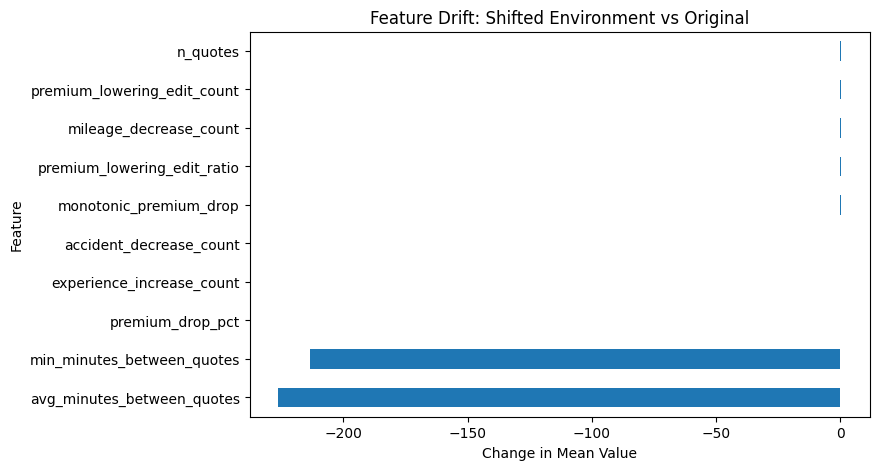

In [148]:
#plotting factor shift
drift_plot = drift_table["absolute_change"].sort_values()

plt.figure(figsize=(8,5))
drift_plot.plot(kind="barh")
plt.title("Feature Drift: Shifted Environment vs Original")
plt.xlabel("Change in Mean Value")
plt.ylabel("Feature")
plt.show()

# **Step 9: Comparing top factor rankings before and after shift**

In [149]:
shifted_rf = RandomForestClassifier(n_estimators=200, random_state=42)
shifted_rf.fit(X_shifted, y_shifted)

original_importance = pd.Series(rf.feature_importances_, index=model_features)
shifted_importance = pd.Series(shifted_rf.feature_importances_, index=model_features)

importance_compare = pd.DataFrame({
    "original_importance": original_importance,
    "shifted_importance": shifted_importance
})

importance_compare["change"] = (
    importance_compare["shifted_importance"] - importance_compare["original_importance"]
)

importance_compare.sort_values("original_importance", ascending=False)

,original_importance,shifted_importance,change
avg_minutes_between_quotes,0.387999,0.269613,-0.118386
min_minutes_between_quotes,0.179549,0.178942,-0.000607
mileage_decrease_count,0.160499,0.131358,-0.029140
premium_drop_pct,0.108735,0.178645,0.069910
n_quotes,0.060738,0.134374,0.073636
experience_increase_count,0.048247,0.035303,-0.012944
premium_lowering_edit_ratio,0.020352,0.025112,0.004760
premium_lowering_edit_count,0.018991,0.027553,0.008562
accident_decrease_count,0.008711,0.012227,0.003516
monotonic_premium_drop,0.006179,0.006872,0.000693


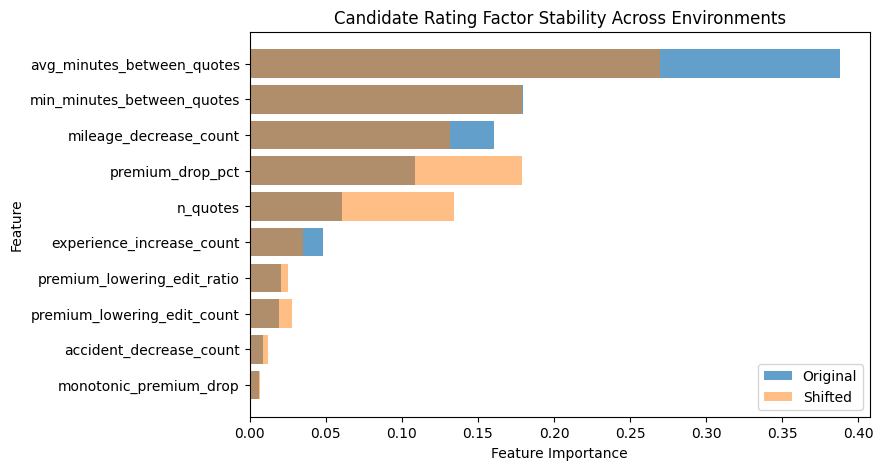

In [150]:
importance_compare_sorted = importance_compare.sort_values("original_importance")

plt.figure(figsize=(8,5))
plt.barh(importance_compare_sorted.index, importance_compare_sorted["original_importance"], alpha=0.7, label="Original")
plt.barh(importance_compare_sorted.index, importance_compare_sorted["shifted_importance"], alpha=0.5, label="Shifted")
plt.title("Candidate Rating Factor Stability Across Environments")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.legend()
plt.show()

In [151]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X,
    y,
    cv=cv,
    scoring=["precision", "recall", "f1"]
)

print("CV Precision:", cv_results["test_precision"].mean())
print("CV Recall:", cv_results["test_recall"].mean())
print("CV F1:", cv_results["test_f1"].mean())

CV Precision: 0.8027393296358813
CV Recall: 0.803448275862069
CV F1: 0.8023593858154022


In [152]:
features_df["manipulation_risk_score"] = features_df["rf_prob_oof"]

features_df["risk_band"] = pd.cut(
    features_df["manipulation_risk_score"],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=["Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

features_df[["customer_id", "manipulation_risk_score", "risk_band"]].head()

,customer_id,manipulation_risk_score,risk_band
0,1,0.00,Low
1,2,0.09,Low
2,3,0.00,Low
3,4,0.01,Low
4,5,0.00,Low


In [153]:
action_map = {
    "Low": "No action",
    "Moderate": "Prompt customer to confirm details",
    "High": "Request additional evidence / validation",
    "Very High": "Escalate for manual review"
}

features_df["recommended_action"] = features_df["risk_band"].map(action_map)
features_df[["customer_id", "manipulation_risk_score", "risk_band", "recommended_action"]].head(10)

,customer_id,manipulation_risk_score,risk_band,recommended_action
0,1,0.000,Low,No action
1,2,0.090,Low,No action
2,3,0.000,Low,No action
3,4,0.010,Low,No action
4,5,0.000,Low,No action
5,6,0.010,Low,No action
6,7,0.000,Low,No action
7,8,0.000,Low,No action
8,9,0.115,Low,No action
9,10,0.015,Low,No action


In [154]:
action_summary = features_df["recommended_action"].value_counts()
action_summary

,count
recommended_action,
No action,641
Escalate for manual review,170
Prompt customer to confirm details,111
Request additional evidence / validation,78


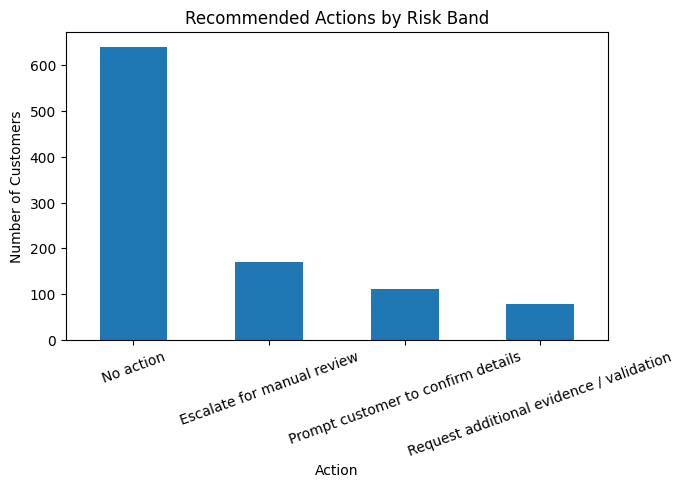

In [155]:
plt.figure(figsize=(7,4))
action_summary.plot(kind="bar")
plt.title("Recommended Actions by Risk Band")
plt.xlabel("Action")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [156]:
pd.crosstab(features_df["label"], features_df["recommended_action"])

recommended_action,No action,Prompt customer to confirm details,Request additional evidence / validation,Escalate for manual review
label,,,,
0,616,61,20,13
1,25,50,58,157
